# Quick exercise
Generate some data;
Compute sample mean and sample variance;
Do it many times;
Estimate the errors;
Compare with the expressions: $\sigma_{x_{mean}}=s/\sqrt(N)$ and $\sigma_s=s/\sqrt(2(N-1))=\sqrt(N/(2(N-1))\sigma_{x_{mean}}$

In [5]:
import numpy as np

# Simulation parameters
mu, sigma_true = 5.0, 2.0 
N = 100                   
n_experiments = 10000     #Loweing this value discrepancies will arise in the two estimated errors

means = []
stds = []

for _ in range(n_experiments):
    # Generate N points from a normal distribution
    sample = np.random.normal(mu, sigma_true, N)
    
    
    means.append(np.mean(sample))
    stds.append(np.std(sample))

# Compute empirical error for the estimates
err_mean_empirical = np.std(means)
err_std_empirical = np.std(stds)

# Compute theoretical value
s_avg = np.mean(stds)
err_mean_theoretical = s_avg / np.sqrt(N)
err_std_theoretical = s_avg / np.sqrt(2 * (N - 1))

print(f"--- Results for N points={N} ---")
print(f"Mean error:   empirical = {err_mean_empirical:.4f} | theoretical = {err_mean_theoretical:.4f}")
print(f"St. dev. error: empirical = {err_std_empirical:.4f} | theoretical = {err_std_theoretical:.4f}")

--- Results for N points=100 ---
Mean error:   empirical = 0.1975 | theoretical = 0.1986
St. dev. error: empirical = 0.1420 | theoretical = 0.1411


# A nasty integral
Using Monte Carlo integration, check that
$\int_0^\inf x^3 exp(-\frac{x^2}{2 \sigma^2})dx = 2\sigma^4$

Does the result converge with the number of samples? And how does the error go down?
Do it many times. For a given N, how are the result distributed? We'll talk about model fitting at lenght later on, but for now try to fit it by hand with a parametrized model. (If N is large enough you should get something that looks very accurate! And if N is small?)
How does the distribution change if N increases?

(Hint: think about sample mean and sample variance)

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

I take as $f(x) = x^3$ and $p(x)=\frac{1}{\sqrt(2\pi\sigma^2)}exp(-\frac{x^2}{2 \sigma^2})$

However the integral is limited to positive value of x, so the sampling has to be limited to the semigaussian and normalize the integral.

In [33]:
sigma=2 #Take a value
expected_result = 2*sigma**4

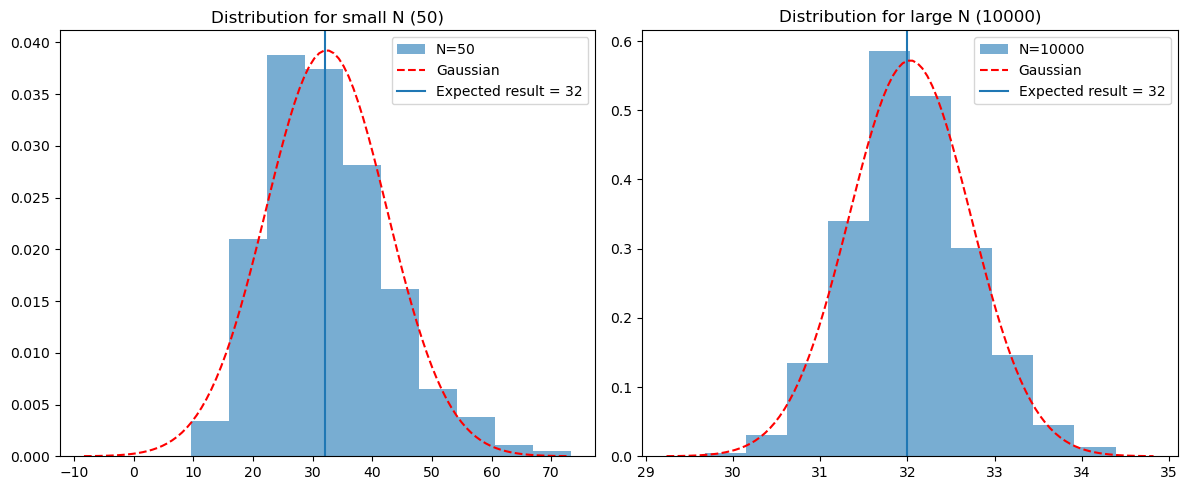

In [35]:
def mc_int(N):
    # Importance sampling using the Half-Normal distribution
    xi = np.abs(np.random.normal(0, sigma, N))
    # Normalization: sqrt(2*pi*sigma^2) / 2
    return np.sqrt(np.pi * sigma**2 / 2) * np.mean(xi**3)

# Comparing two different N values
N_small = 50
N_large = 10000
iterations = 2000

results_small = [mc_int(N_small) for _ in range(iterations)]
results_large = [mc_step(N_large) for _ in range(iterations)]

plt.figure(figsize=(12, 5))

# Plot for small N
plt.subplot(1, 2, 1)
plt.hist(results_small, density=True, alpha=0.6, label=f'N={N_small}')
mu_s, std_s = np.mean(results_small), np.std(results_small)
x = np.linspace(mu_s - 4*std_s, mu_s + 4*std_s, 100)
plt.plot(x, norm.pdf(x, mu_s, std_s), 'r--', label='Gaussian')
plt.axvline(expected_result, label=f'Expected result = {expected_result}')
plt.title(f'Distribution for small N ({N_small})')
plt.legend()

# Plot for large N
plt.subplot(1, 2, 2)
plt.hist(results_large, density=True, alpha=0.6, label=f'N={N_large}')
mu_l, std_l = np.mean(results_large), np.std(results_large)
x = np.linspace(mu_l - 4*std_l, mu_l + 4*std_l, 100)
plt.plot(x, norm.pdf(x, mu_l, std_l), 'r--', label='Gaussian')
plt.axvline(expected_result, label=f'Expected result = {expected_result}')
plt.title(f'Distribution for large N ({N_large})')
plt.legend()

plt.tight_layout()
plt.show()

Physical reasoning:

Performing Monte Carlo integration is essentially estimating a population mean using a finite number of samples $N$. According to the Central Limit Theorem, as $N$ increases, the distribution of the sample mean tends towards a Gaussian, regardless of the underlying distribution of the samples.

The distribution of the results should be centered around the true value of the integral,
The variance of the Monte Carlo estimate is given by:
$$\sigma^2_{MC} = \frac{\sigma^2_{fun}}{N}$$
where $\sigma^2_{fun}$ is the variance of the function values $f(x_i)$ that is getting averaged. The error decreases as $1/\sqrt{N}$.

Effect of $N$ on the Distribution:
* Small $N$: The distribution might look slightly non-Gaussian (asymmetric or "skewed"). This happens because the function $x^3$ is highly non-linear, and with few samples, the "tails" of the distribution aren't sampled well.
* Large $N$: The distribution becomes perfectly Gaussian and significantly narrower. Specifically, if you increase $N$ by a factor of 100, the width of the histogram (the uncertainty) will shrink by a factor of 10.

# Kicking horses
A famous early application of low-number statistics was an analysis of Prussian cavalryman horse-kick deaths by Bortkiewicz in 1898.

He studied the distribution of 122 men kicked to death by horses among 10 Prussian army corps within 20 years (so a total number of corpes of 200). He recorded the number of corps with a given number of deaths:
| Number of deaths | Number of groups |
| :---: | :---: | 
| 0 | 109 | 
| 1 | 65 | 
| 2 | 22 | 
| 3 | 3 | 
| 4 | 1 |

Plot the resulting probability distribution. Careful with the normalization
How does it look like? Again try to fit it by hand.
(Hint: think about sample mean and sample variance)

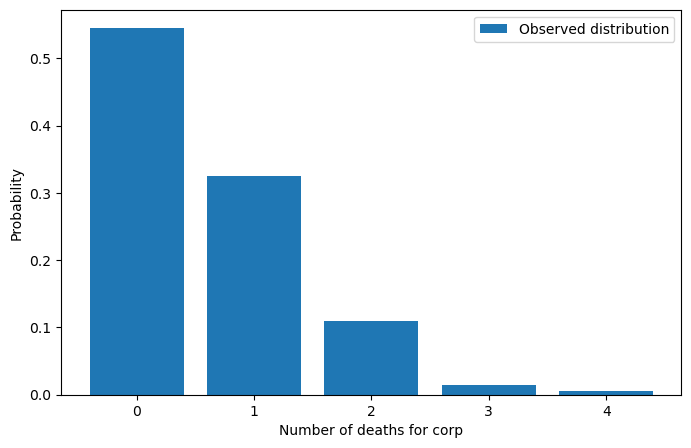

In [47]:
deaths = np.array([0, 1, 2, 3, 4])
groups = np.array([109, 65, 22, 3, 1])
total_groups = np.sum(groups)

# Normalization for probability
observed_prob = groups / total_groups

# Plot della distribuzione osservata
plt.figure(figsize=(8, 5))
plt.bar(deaths, observed_prob,  label='Observed distribution')
plt.xlabel('Number of deaths for corp')
plt.ylabel('Probability')
plt.legend()
plt.show()

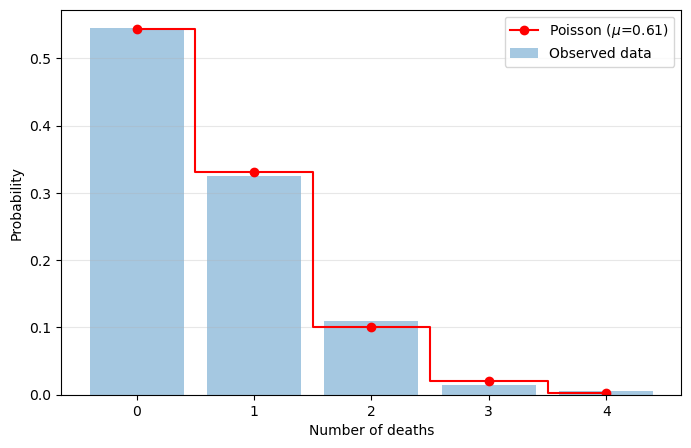

In [50]:
from scipy.stats import poisson

# Sample mean
mean_obs = np.sum(deaths * groups) / total_groups
var_obs = np.sum(counts * (deaths - mean_obs)**2) / (total_groups - 1)

# Compute PMF (Probability Mass Function) by using scipy (discrete values)
# poisson.pmf(k, mu) where as mu I take the one observed
theoretical_pmf = poisson.pmf(deaths, mu=mean_obs)

plt.figure(figsize=(8, 5))
plt.bar(deaths, observed_prob, alpha=0.4, label='Observed data')
plt.step(deaths, theoretical_pmf, where='mid', color='red', label=f'Poisson ($\mu$={mean_obs:.2f})', marker='o')

plt.xlabel('Number of deaths')
plt.ylabel('Probability')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [51]:
print(f"Observed mean: {mean_obs:.3f}")
print(f"Observed variance: {var_obs:.3f}")

Observed mean: 0.610
Observed variance: 0.611


Physical reasoning:

Poisson distribution arises when describing the number of times an event occurs in a fixed interval of time or space, provided that:
1. The events occur independently.
2. The probability of an event in a tiny interval is proportional to the length of the interval.
3. The probability of more than one event in an infinitesimal interval is negligible.

In a Poisson process, the mean must be equal to the variance ($\sigma^2$). 
* From calculations, $\bar{x} \approx 0.61$ and $s^2 \approx 0.61$. 
* This  confirms the horse-kick deaths followed a Poisson distribution. It shows that the deaths were truly random and not caused by systemic issues in specific corps (which would have increased the variance).

This is called "low-number statistics" because the events are rare. Even though there were thousands of soldiers, the expected number of deaths per group is less than 1. This is why the distribution is highly skewed towards zero, with very few cases of 3 or 4 deaths.